In [47]:
import pandas as pd

In [48]:
df = pd.read_csv("../data/shopping_trends_updated.csv")

In [49]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [50]:
df.shape

(3900, 18)

In [51]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [53]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [54]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df["Customer ID"].duplicated().sum()

np.int64(0)

In [57]:
df["Gender"].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [58]:
df["Category"].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [59]:
df["Season"].value_counts()

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

In [60]:
df["Payment Method"].value_counts()

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

In [61]:
print("DATA CLEANING CHECK")
print("-------------------")
print(f"Missing values   : {df.isnull().sum().sum()}")
print(f"Duplicate rows   : {df.duplicated().sum()}")
print(f"Duplicate ID     : {df['Customer ID'].duplicated().sum()}")
print("Status           : Dataset siap untuk EDA")

DATA CLEANING CHECK
-------------------
Missing values   : 0
Duplicate rows   : 0
Duplicate ID     : 0
Status           : Dataset siap untuk EDA


In [62]:
df.groupby("Category")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Category,,,
Clothing,1737,60.025331,104264
Accessories,1240,59.838710,74200
Footwear,599,60.255426,36093
Outerwear,324,57.172840,18524


In [63]:
df.groupby("Gender")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Gender,,,
Male,2652,59.536199,157890
Female,1248,60.249199,75191


In [64]:
df.groupby("Season")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Season,,,
Fall,975,61.556923,60018
Spring,999,58.737738,58679
Winter,971,60.357364,58607
Summer,955,58.405236,55777


In [65]:
df.groupby("Payment Method")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Payment Method,,,
Credit Card,671,60.074516,40310
PayPal,677,59.245199,40109
Cash,670,59.704478,40002
Debit Card,636,60.915094,38742
Venmo,634,58.949527,37374
Bank Transfer,612,59.712418,36544


In [66]:
df.groupby("Subscription Status")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Subscription Status,,,
No,2847,59.865121,170436
Yes,1053,59.491928,62645


In [67]:
df.groupby("Discount Applied")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Discount Applied,,,
No,2223,60.130454,133670
Yes,1677,59.279070,99411


In [68]:
df.groupby("Promo Code Used")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Promo Code Used,,,
No,2223,60.130454,133670
Yes,1677,59.279070,99411


In [69]:
df.groupby("Shipping Type")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Shipping Type,,,
Free Shipping,675,60.410370,40777
Express,646,60.475232,39067
Store Pickup,650,59.893846,38931
Standard,654,58.460245,38233
2-Day Shipping,627,60.733652,38080
Next Day Air,648,58.631173,37993


In [70]:
df.groupby("Frequency of Purchases")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Frequency of Purchases,,,
Every 3 Months,584,60.082192,35088
Annually,572,60.173077,34419
Quarterly,563,59.984014,33771
Bi-Weekly,547,60.694698,33200
Monthly,553,59.330922,32810
Fortnightly,542,59.053506,32007
Weekly,539,58.972171,31786


In [71]:
df.groupby("Item Purchased")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Item Purchased,,,
Blouse,171,60.877193,10410
Shirt,169,61.136095,10332
Dress,166,62.168675,10320
Pants,171,59.005848,10090
Jewelry,171,58.538012,10010
Sunglasses,161,59.931677,9649
Belt,161,59.844720,9635
Scarf,157,60.898089,9561
Sweater,164,57.695122,9462


In [72]:
df.groupby("Location")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Location,,,
Montana,96,60.250000,5784
Illinois,92,61.054348,5617
California,95,59.000000,5605
Idaho,93,60.075269,5587
Nevada,87,63.379310,5514
Alabama,89,59.112360,5261
New York,87,60.425287,5257
North Dakota,83,62.891566,5220
West Virginia,81,63.876543,5174


In [73]:
df.groupby("Age")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Age,,,
49,84,66.095238,5552
69,88,62.318182,5484
25,85,63.200000,5372
41,86,61.418605,5282
54,83,63.638554,5282
57,87,59.770115,5200
28,79,64.607595,5104
19,81,61.000000,4941
50,83,59.397590,4930


In [74]:
df.groupby("Size")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Size,,,
M,1755,59.924217,105167
L,1053,58.563153,61667
S,663,61.037707,40468
XL,429,60.090909,25779


In [75]:
df.groupby("Color")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Color,,,
Green,169,65.704142,11104
Teal,172,60.808140,10459
Yellow,174,59.241379,10308
Olive,177,58.146893,10292
Cyan,166,61.891566,10274
Violet,166,61.716867,10245
Gray,159,62.490566,9936
Silver,173,56.832370,9832
Black,167,58.401198,9753


In [76]:
df.groupby("Review Rating")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Review Rating,,,
3.4,182,59.005495,10739
4.0,181,59.237569,10722
4.9,166,63.885542,10605
4.2,171,60.853801,10406
4.6,174,57.683908,10037
3.0,162,60.728395,9838
3.9,163,58.926380,9605
2.9,170,56.470588,9600
4.4,158,60.525316,9563


In [77]:
df.groupby("Previous Purchases")["Purchase Amount (USD)"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

,count,mean,sum
Previous Purchases,,,
48,90,63.588889,5723
47,90,62.655556,5639
5,87,64.252874,5590
4,91,61.274725,5576
21,96,57.979167,5566
31,97,57.288660,5557
24,91,60.197802,5478
14,92,57.967391,5333
3,91,58.560440,5329


In [78]:
df.select_dtypes(include="number").corr()["Purchase Amount (USD)"].sort_values(ascending=False)

Purchase Amount (USD)    1.000000
Review Rating            0.030776
Customer ID              0.011048
Previous Purchases       0.008063
Age                     -0.010424
Name: Purchase Amount (USD), dtype: float64

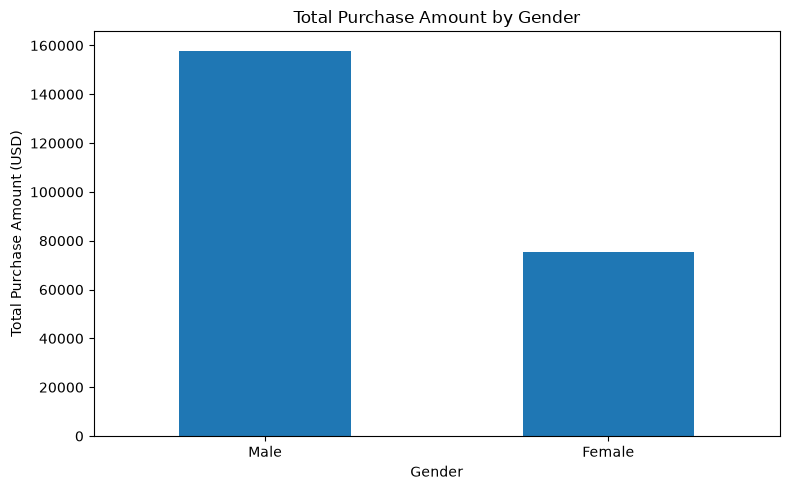

In [79]:
import matplotlib.pyplot as plt

gender_sales = (
    df.groupby("Gender")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

gender_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [80]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [81]:
import pandas as pd

df = pd.read_csv("../data/shopping_trends_updated.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


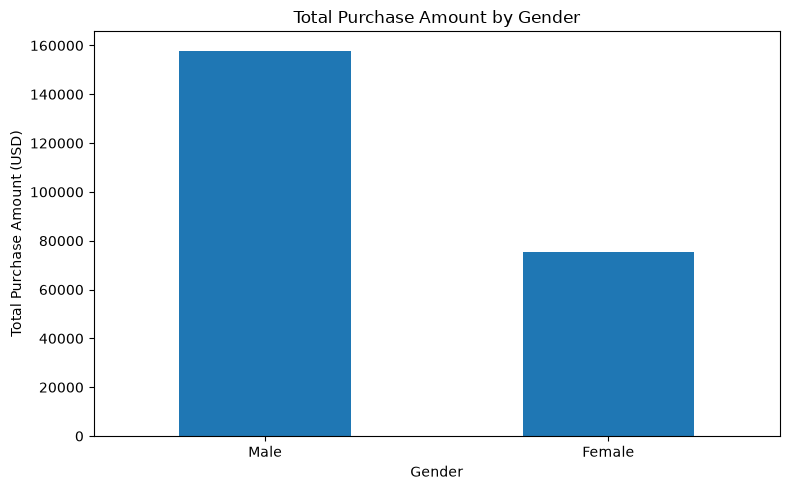

In [82]:
import matplotlib.pyplot as plt

gender_sales = (
    df.groupby("Gender")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

gender_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

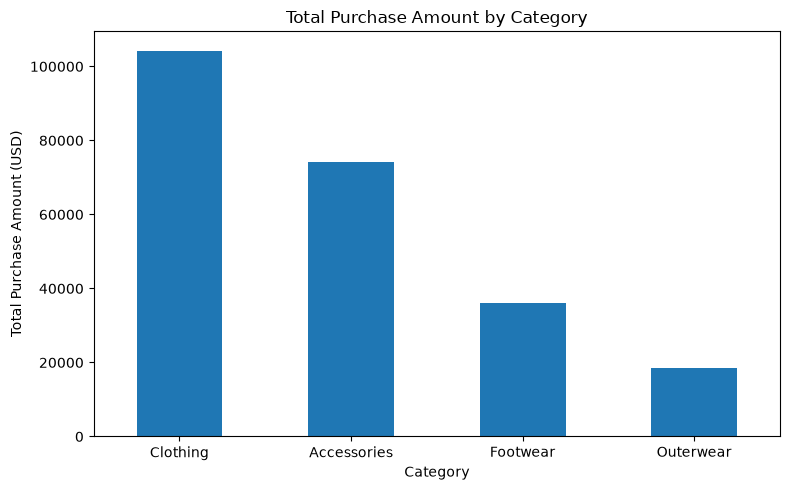

In [83]:
category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

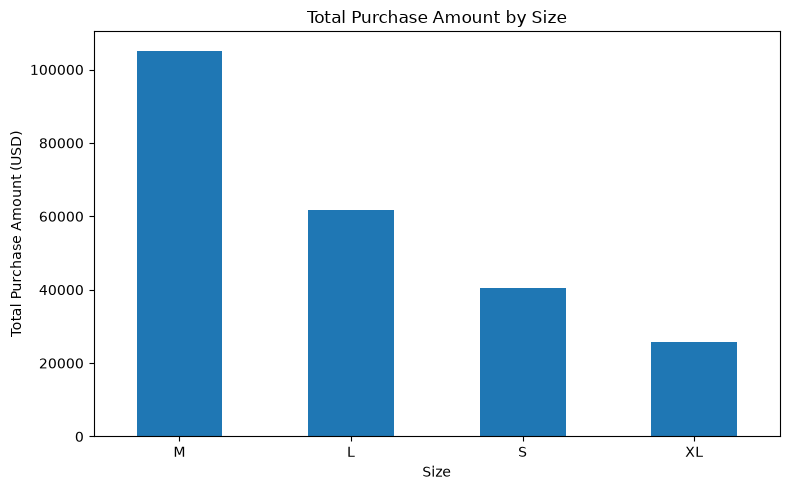

In [84]:
size_sales = (
    df.groupby("Size")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

size_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Size")
plt.xlabel("Size")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

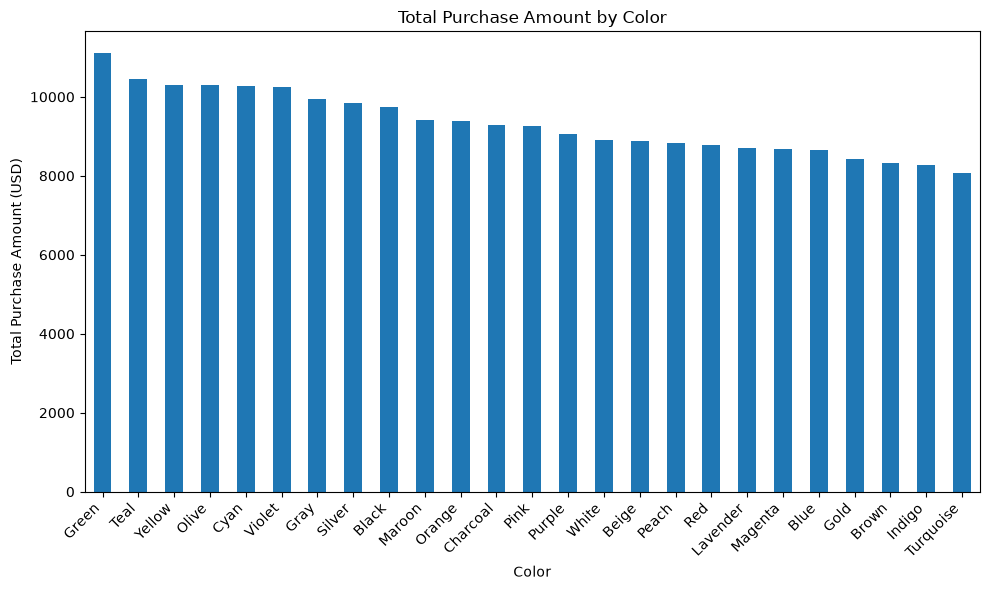

In [85]:
color_sales = (
    df.groupby("Color")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

color_sales.plot(kind="bar", figsize=(10, 6))

plt.title("Total Purchase Amount by Color")
plt.xlabel("Color")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

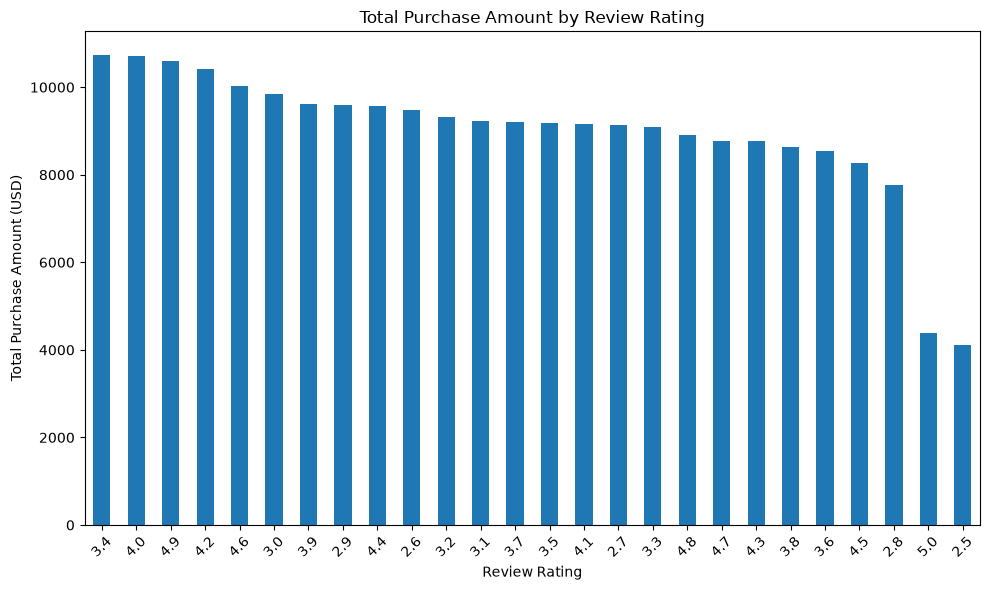

In [86]:
rating_sales = (
    df.groupby("Review Rating")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

rating_sales.plot(kind="bar", figsize=(10, 6))

plt.title("Total Purchase Amount by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
age_group_sales = (
    df.groupby("Age")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

age_group_sales.head(15)

Age
49    5552
69    5484
25    5372
41    5282
54    5282
57    5200
28    5104
19    4941
50    4930
31    4864
62    4809
32    4796
53    4752
37    4737
43    4698
Name: Purchase Amount (USD), dtype: int64

In [88]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 24, 34, 44, 54, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"]
)

age_group_sales = (
    df.groupby("Age Group", observed=False)["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

age_group_sales

Age Group
55+      69590
25-34    45400
45-54    45370
35-44    43463
18-24    29258
Name: Purchase Amount (USD), dtype: int64

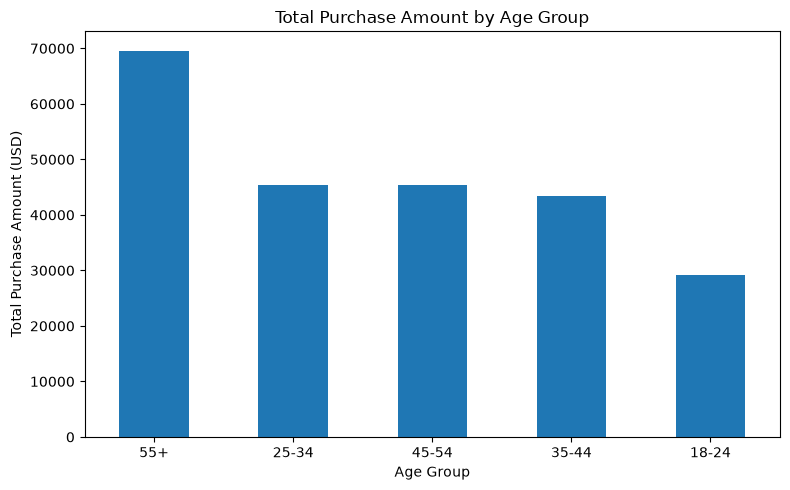

In [89]:
import matplotlib.pyplot as plt

age_group_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [90]:
subscription_sales = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

subscription_sales

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64

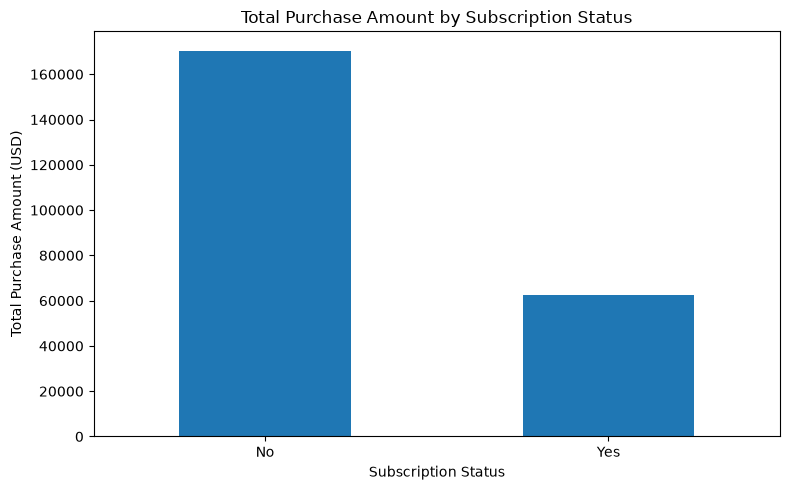

In [91]:
import matplotlib.pyplot as plt

subscription_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [92]:
payment_sales = (
    df.groupby("Payment Method")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

Payment Method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: Purchase Amount (USD), dtype: int64

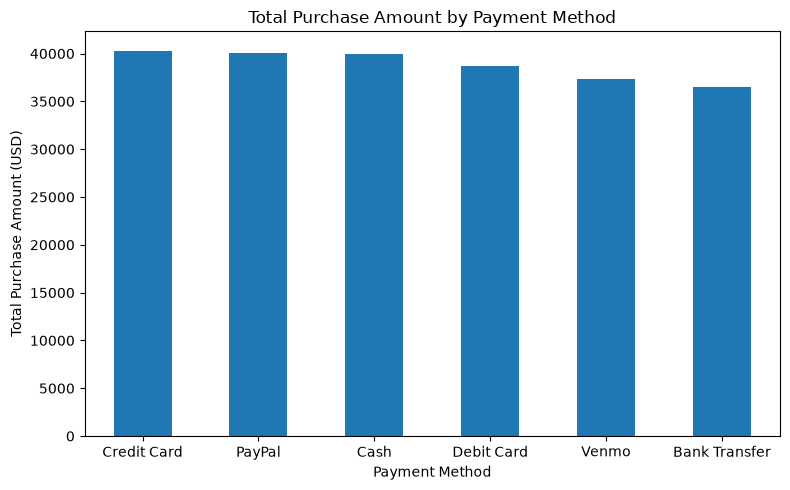

In [93]:
payment_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [94]:
frequency_sales = (
    df.groupby("Frequency of Purchases")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

frequency_sales

Frequency of Purchases
Every 3 Months    35088
Annually          34419
Quarterly         33771
Bi-Weekly         33200
Monthly           32810
Fortnightly       32007
Weekly            31786
Name: Purchase Amount (USD), dtype: int64

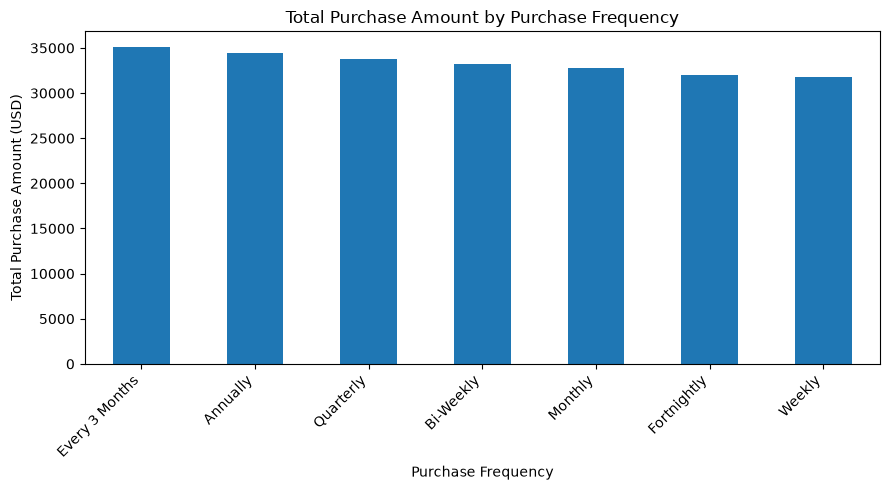

In [95]:
frequency_sales.plot(kind="bar", figsize=(9, 5))

plt.title("Total Purchase Amount by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [96]:
discount_sales = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

discount_sales

Discount Applied
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64

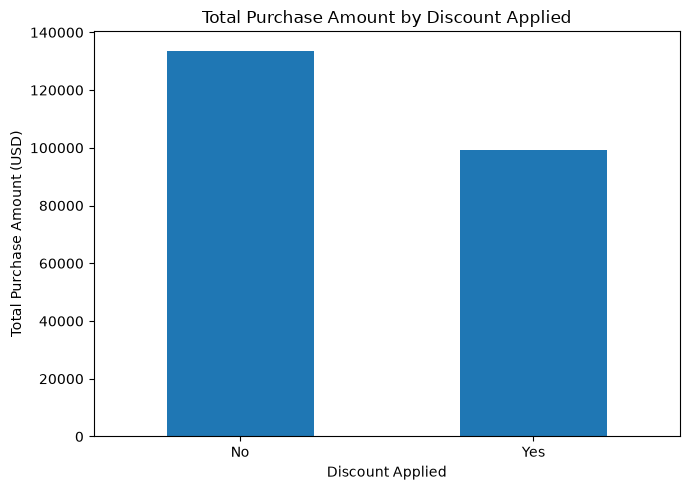

In [97]:
discount_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Total Purchase Amount by Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [98]:
previous_purchase_sales = (
    df.groupby("Previous Purchases")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

previous_purchase_sales.head(15)

Previous Purchases
48    5723
47    5639
5     5590
4     5576
21    5566
31    5557
24    5478
14    5333
3     5329
20    5137
33    5083
50    5026
32    4984
18    4968
28    4951
Name: Purchase Amount (USD), dtype: int64

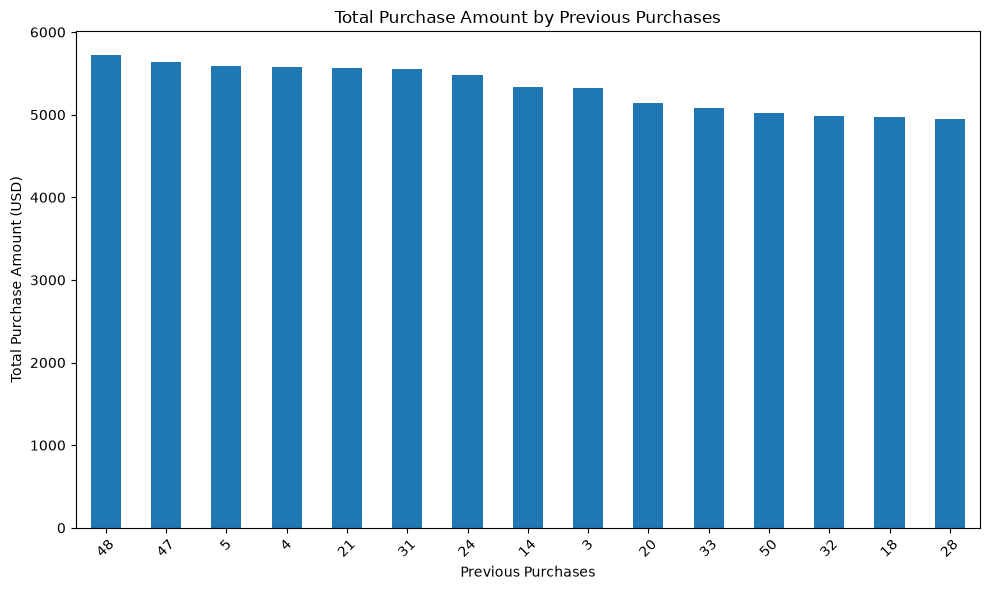

In [99]:
previous_purchase_sales = (
    df.groupby("Previous Purchases")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

previous_purchase_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total Purchase Amount by Previous Purchases")
plt.xlabel("Previous Purchases")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [100]:
preferred_payment_sales = (
    df.groupby("Payment Method")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

preferred_payment_sales

Payment Method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: Purchase Amount (USD), dtype: int64

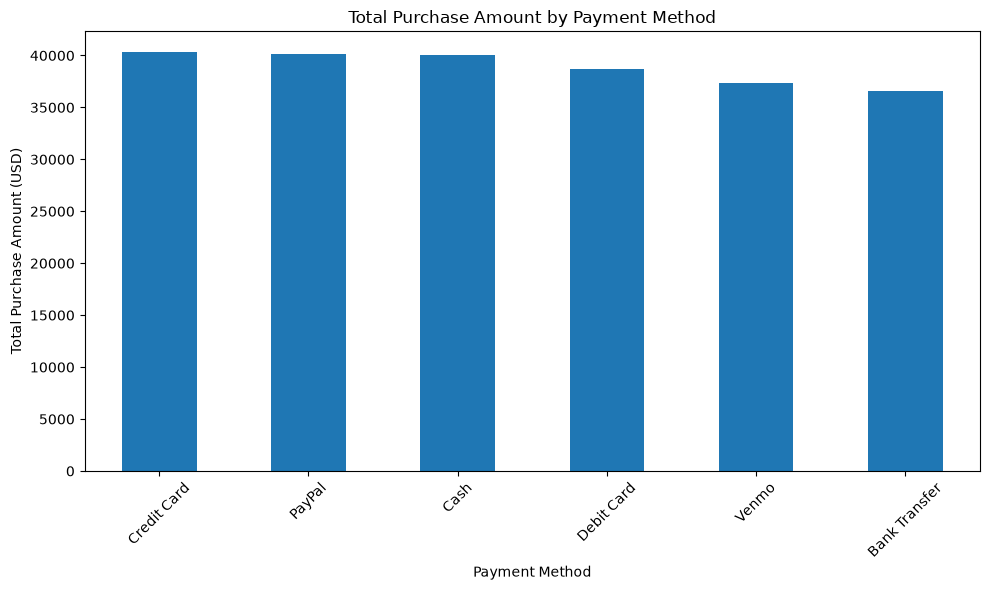

In [101]:
preferred_payment_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [102]:
category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

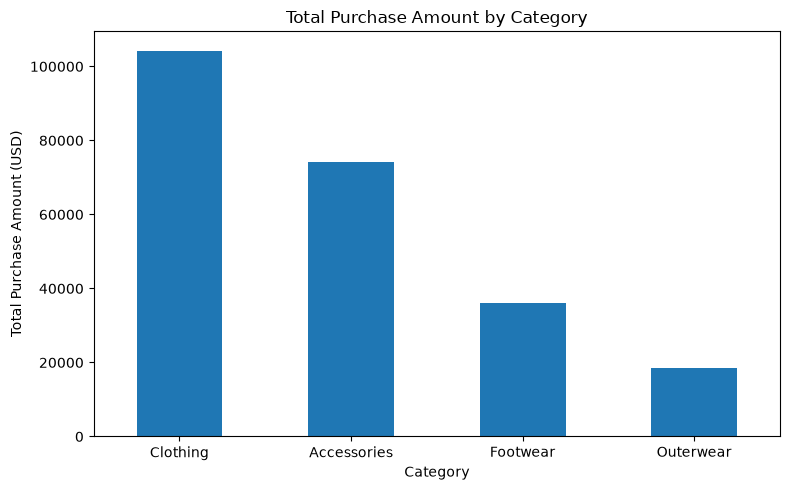

In [103]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [104]:
gender_sales = (
    df.groupby("Gender")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

gender_sales

Gender
Male      157890
Female     75191
Name: Purchase Amount (USD), dtype: int64

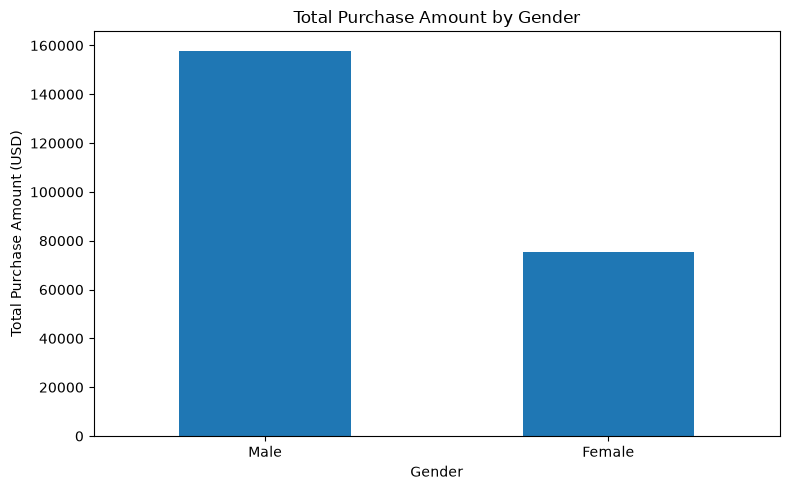

In [105]:
plt.figure(figsize=(8, 5))

gender_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [106]:
season_sales = (
    df.groupby("Season")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

season_sales

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64

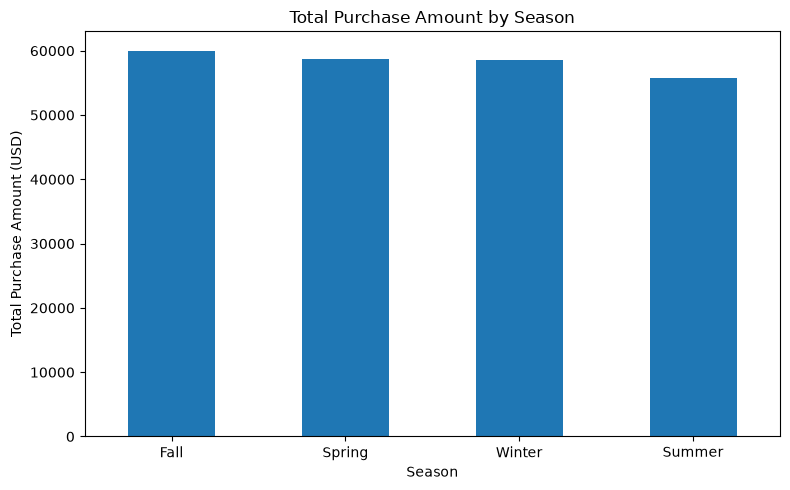

In [107]:
plt.figure(figsize=(8, 5))

season_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Season")
plt.xlabel("Season")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [108]:
age_sales = (
    df.groupby("Age")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

age_sales.head(15)

Age
49    5552
69    5484
25    5372
41    5282
54    5282
57    5200
28    5104
19    4941
50    4930
31    4864
62    4809
32    4796
53    4752
37    4737
43    4698
Name: Purchase Amount (USD), dtype: int64

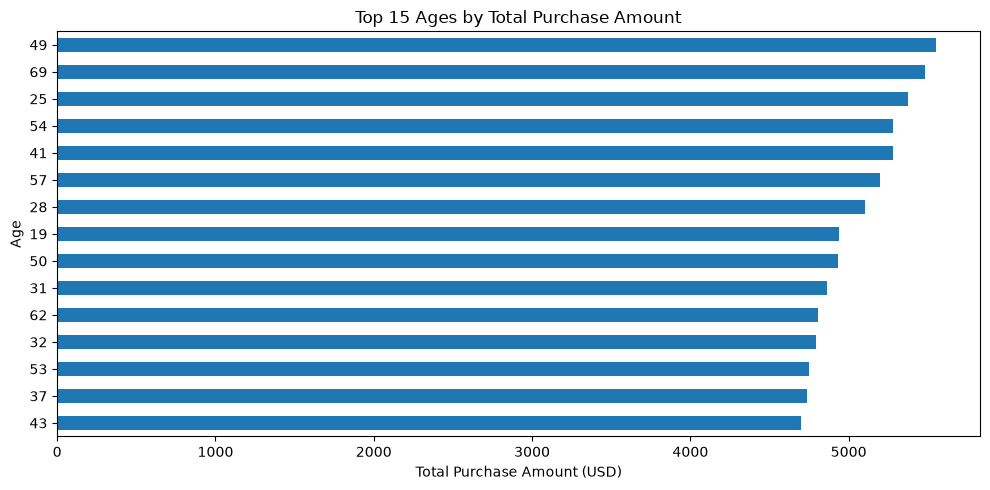

In [109]:
plt.figure(figsize=(10, 5))

age_sales.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Ages by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [110]:
rating_sales = (
    df.groupby("Review Rating")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

rating_sales

Review Rating
3.4    10739
4.0    10722
4.9    10605
4.2    10406
4.6    10037
3.0     9838
3.9     9605
2.9     9600
4.4     9563
2.6     9471
3.2     9320
3.1     9227
3.7     9200
3.5     9178
4.1     9170
2.7     9142
3.3     9099
4.8     8911
4.7     8774
4.3     8772
3.8     8644
3.6     8541
4.5     8269
2.8     7761
5.0     4376
2.5     4111
Name: Purchase Amount (USD), dtype: int64

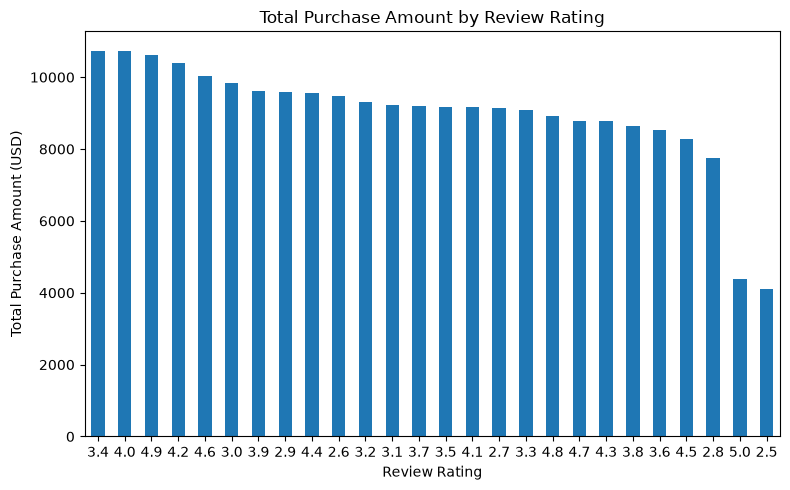

In [111]:
plt.figure(figsize=(8, 5))

rating_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [112]:
item_sales = (
    df.groupby("Item Purchased")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

item_sales.head(15)

Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Skirt          9402
Hat            9375
Coat           9275
Socks          9252
Jacket         9249
Name: Purchase Amount (USD), dtype: int64

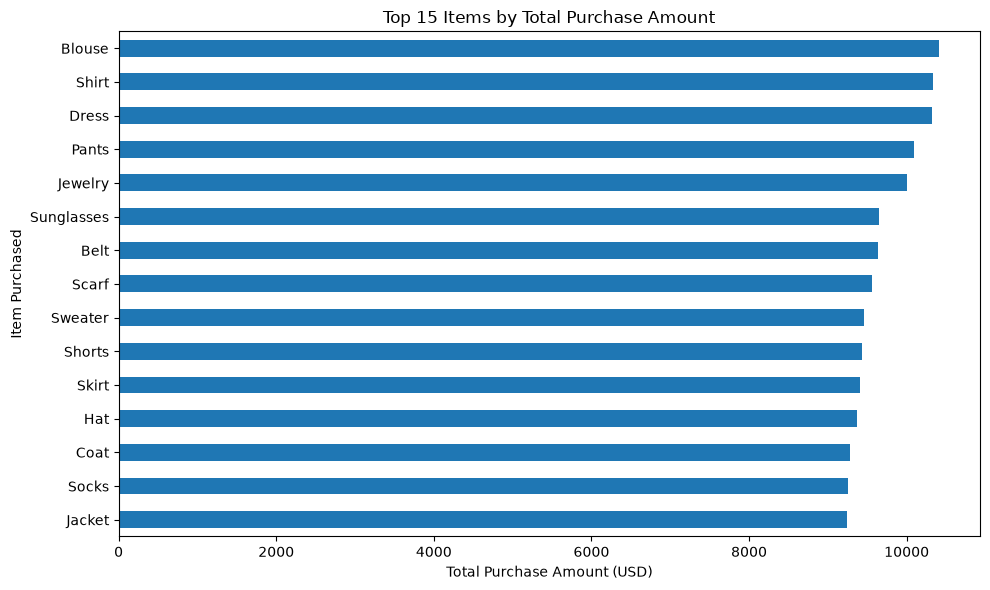

In [113]:
plt.figure(figsize=(10, 6))

item_sales.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Items by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Item Purchased")

plt.tight_layout()
plt.show()

In [114]:
location_sales = (
    df.groupby("Location")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

location_sales.head(15)

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
New Mexico       5014
Minnesota        4977
Pennsylvania     4926
Mississippi      4883
Alaska           4867
Name: Purchase Amount (USD), dtype: int64

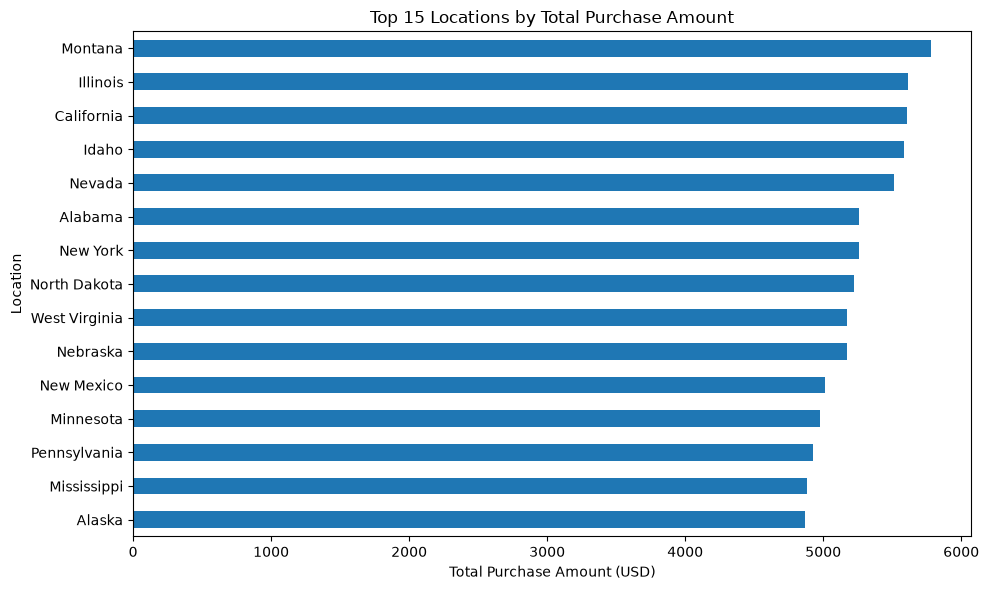

In [115]:
plt.figure(figsize=(10, 6))

location_sales.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Locations by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [116]:
subscription_sales = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

subscription_sales

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64

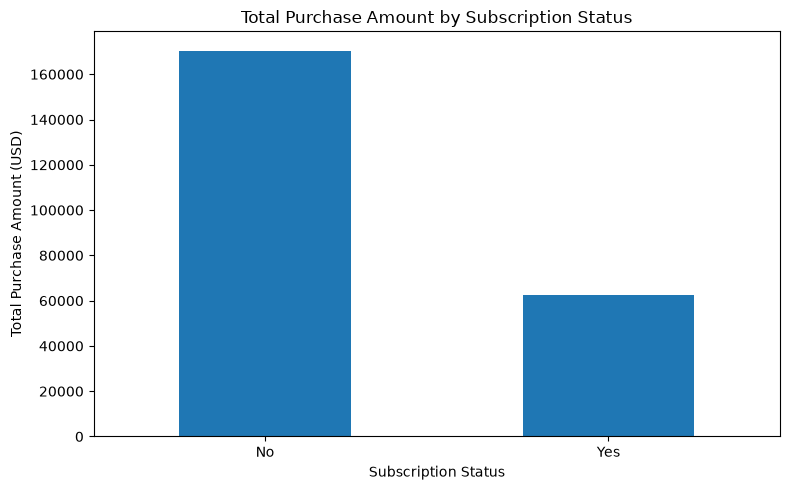

In [117]:
plt.figure(figsize=(8, 5))

subscription_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [118]:
discount_sales = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

discount_sales

Discount Applied
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64

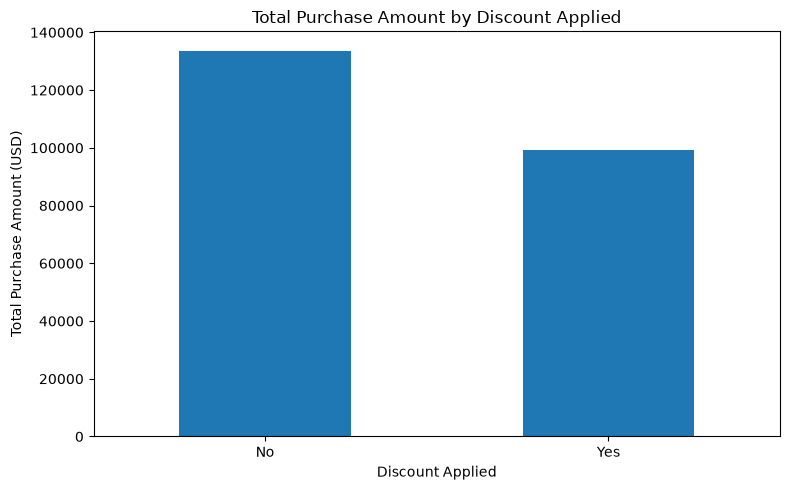

In [119]:
plt.figure(figsize=(8, 5))

discount_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [120]:
previous_purchase_sales = (
    df.groupby("Previous Purchases")["Purchase Amount (USD)"]
    .sum()
    .sort_values(ascending=False)
)

previous_purchase_sales.head(15)

Previous Purchases
48    5723
47    5639
5     5590
4     5576
21    5566
31    5557
24    5478
14    5333
3     5329
20    5137
33    5083
50    5026
32    4984
18    4968
28    4951
Name: Purchase Amount (USD), dtype: int64

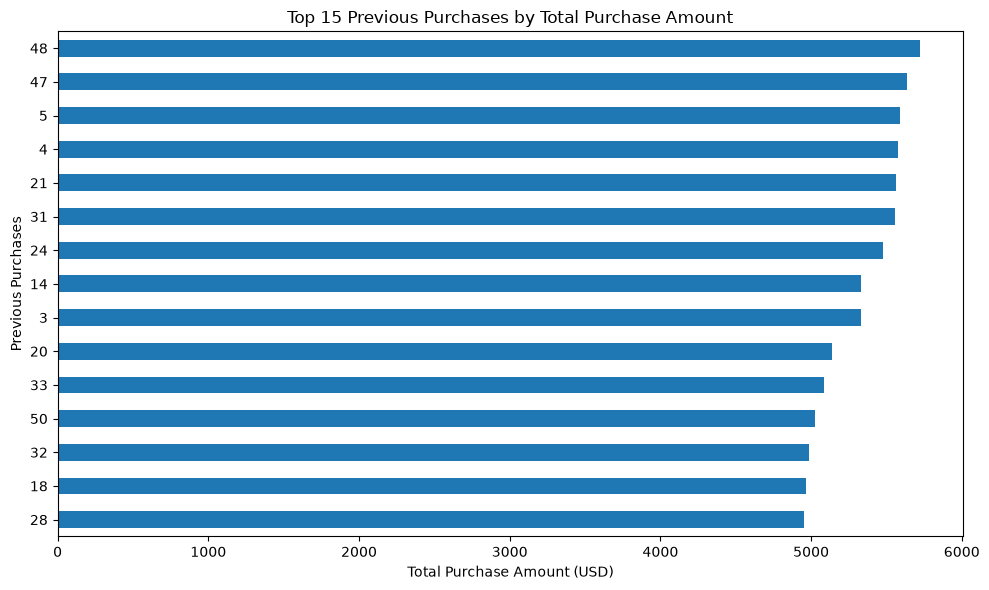

In [121]:
plt.figure(figsize=(10, 6))

previous_purchase_sales.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Previous Purchases by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Previous Purchases")

plt.tight_layout()
plt.show()

In [122]:
print("=== PROJECT 02: CUSTOMER SHOPPING TRENDS ===")
print()
print("KEY BUSINESS INSIGHTS")
print()

print("1. Category Performance:")
print("   Clothing merupakan kategori dengan total purchase amount tertinggi.")

print()
print("2. Customer Gender:")
print("   Customer Male memberikan total purchase amount lebih tinggi dibanding Female.")

print()
print("3. Season Performance:")
print("   Fall memiliki total purchase amount tertinggi, sedangkan Summer terendah.")

print()
print("4. Payment Method:")
print("   Credit Card memiliki total purchase amount tertinggi di antara metode pembayaran.")

print()
print("5. Subscription:")
print("   Customer tanpa subscription menghasilkan total purchase amount lebih tinggi.")

print()
print("6. Discount:")
print("   Customer tanpa discount menghasilkan total purchase amount lebih tinggi.")

print()
print("7. Customer Behavior:")
print("   Previous Purchases menunjukkan adanya kelompok customer dengan riwayat pembelian tinggi.")

=== PROJECT 02: CUSTOMER SHOPPING TRENDS ===

KEY BUSINESS INSIGHTS

1. Category Performance:
   Clothing merupakan kategori dengan total purchase amount tertinggi.

2. Customer Gender:
   Customer Male memberikan total purchase amount lebih tinggi dibanding Female.

3. Season Performance:
   Fall memiliki total purchase amount tertinggi, sedangkan Summer terendah.

4. Payment Method:
   Credit Card memiliki total purchase amount tertinggi di antara metode pembayaran.

5. Subscription:
   Customer tanpa subscription menghasilkan total purchase amount lebih tinggi.

6. Discount:
   Customer tanpa discount menghasilkan total purchase amount lebih tinggi.

7. Customer Behavior:
   Previous Purchases menunjukkan adanya kelompok customer dengan riwayat pembelian tinggi.


In [123]:
print("=== PROJECT 02: CUSTOMER SHOPPING TRENDS ===")
print("\nBUSINESS RECOMMENDATIONS")

print("""
1. Focus on Clothing Category
   Clothing memiliki total purchase amount tertinggi.
   Bisnis dapat meningkatkan stok, variasi produk, dan promosi
   pada kategori Clothing karena memiliki kontribusi penjualan terbesar.

2. Optimize Payment Methods
   Credit Card memiliki total purchase amount tertinggi.
   Bisnis dapat memberikan promotional campaign atau loyalty rewards
   untuk meningkatkan transaksi melalui metode pembayaran tersebut.

3. Improve Female Customer Engagement
   Total purchase amount customer Male lebih tinggi dibanding Female.
   Bisnis dapat meningkatkan campaign, product recommendation,
   dan promotion yang lebih relevan untuk customer Female.

4. Seasonal Marketing Strategy
   Fall menghasilkan total purchase amount tertinggi,
   sedangkan Summer memiliki nilai terendah.
   Campaign dan inventory dapat disesuaikan dengan pola seasonal demand.

5. Subscription Strategy
   Customer tanpa subscription menghasilkan total purchase amount
   lebih tinggi dibanding customer dengan subscription.
   Bisnis perlu mengevaluasi kembali value dan benefit subscription
   agar lebih menarik bagi customer.

6. Discount Optimization
   Customer tanpa discount menghasilkan total purchase amount
   lebih tinggi dibanding customer dengan discount.
   Discount sebaiknya digunakan secara targeted untuk meningkatkan
   conversion atau customer retention, bukan diberikan secara luas.

7. Customer Retention
   Data Previous Purchases menunjukkan adanya customer dengan
   riwayat pembelian tinggi.
   Customer tersebut dapat menjadi target loyalty program,
   personalized offers, dan retention campaign.
""")

=== PROJECT 02: CUSTOMER SHOPPING TRENDS ===

BUSINESS RECOMMENDATIONS

1. Focus on Clothing Category
   Clothing memiliki total purchase amount tertinggi.
   Bisnis dapat meningkatkan stok, variasi produk, dan promosi
   pada kategori Clothing karena memiliki kontribusi penjualan terbesar.

2. Optimize Payment Methods
   Credit Card memiliki total purchase amount tertinggi.
   Bisnis dapat memberikan promotional campaign atau loyalty rewards
   untuk meningkatkan transaksi melalui metode pembayaran tersebut.

3. Improve Female Customer Engagement
   Total purchase amount customer Male lebih tinggi dibanding Female.
   Bisnis dapat meningkatkan campaign, product recommendation,
   dan promotion yang lebih relevan untuk customer Female.

4. Seasonal Marketing Strategy
   Fall menghasilkan total purchase amount tertinggi,
   sedangkan Summer memiliki nilai terendah.
   Campaign dan inventory dapat disesuaikan dengan pola seasonal demand.

5. Subscription Strategy
   Customer tanpa subscr

In [124]:
print("=== FINAL CONCLUSION ===")

print("""
Project 02 analyzed customer shopping trends using Python and Pandas.

The analysis identified several important business patterns:

- Clothing is the highest-performing product category.
- Male customers contribute a higher total purchase amount than Female customers.
- Fall generates the highest total purchase amount among seasons.
- Credit Card is the highest-performing payment method.
- Customers without subscription generate higher total purchase amount.
- Customers without discount generate higher total purchase amount.
- Previous purchase behavior can be used to identify valuable customer segments.

These findings can help businesses improve product strategy,
customer segmentation, marketing campaigns, payment strategy,
and customer retention.

This project demonstrates practical data analyst skills including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Aggregation
- GroupBy Analysis
- Data Visualization
- Business Insight Generation
- Business Recommendation
""")

=== FINAL CONCLUSION ===

Project 02 analyzed customer shopping trends using Python and Pandas.

The analysis identified several important business patterns:

- Clothing is the highest-performing product category.
- Male customers contribute a higher total purchase amount than Female customers.
- Fall generates the highest total purchase amount among seasons.
- Credit Card is the highest-performing payment method.
- Customers without subscription generate higher total purchase amount.
- Customers without discount generate higher total purchase amount.
- Previous purchase behavior can be used to identify valuable customer segments.

These findings can help businesses improve product strategy,
customer segmentation, marketing campaigns, payment strategy,
and customer retention.

This project demonstrates practical data analyst skills including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Aggregation
- GroupBy Analysis
- Data Visualization
- Business Insight Generation
- Bus

# Project 02 — Customer Shopping Trends

## Project Overview

This project analyzes customer shopping behavior using Python and Pandas.

The objective is to identify purchasing patterns, customer segments, product performance, and business opportunities from customer shopping data.

## Tools & Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- VS Code

## Analysis Performed

The analysis covers:

1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Category Performance
4. Gender Analysis
5. Seasonal Analysis
6. Payment Method Analysis
7. Age Analysis
8. Review Rating Analysis
9. Product Analysis
10. Location Analysis
11. Subscription Analysis
12. Discount Analysis
13. Previous Purchase Analysis

## Key Business Insights

- Clothing generates the highest total purchase amount.
- Male customers contribute a higher total purchase amount than Female customers.
- Fall generates the highest total purchase amount among seasons.
- Credit Card is the highest-performing payment method.
- Customers without subscription generate higher total purchase amount.
- Customers without discount generate higher total purchase amount.
- Previous purchase behavior can help identify valuable customer segments.

## Business Value

The findings can support business decisions related to:

- Product strategy
- Customer segmentation
- Marketing campaigns
- Promotional strategy
- Payment strategy
- Customer retention

## Conclusion

This project demonstrates practical data analyst skills by transforming raw customer shopping data into meaningful business insights and actionable recommendations.

# Project 02 — Customer Shopping Trends

## Project Overview

This project analyzes customer shopping behavior using Python and Pandas.

The objective is to identify purchasing patterns, customer segments, product performance, and business opportunities from customer shopping data.

## Tools & Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- VS Code

## Analysis Performed

The analysis covers:

1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Category Performance Analysis
4. Gender Analysis
5. Seasonal Analysis
6. Payment Method Analysis
7. Age Analysis
8. Review Rating Analysis
9. Product Analysis
10. Location Analysis
11. Subscription Analysis
12. Discount Analysis
13. Previous Purchase Analysis

## Key Business Insights

- Clothing generates the highest total purchase amount.
- Male customers contribute a higher total purchase amount than female customers.
- Fall generates the highest total purchase amount among seasons.
- Credit Card is the highest-performing payment method.
- Customers without subscription generate higher total purchase amounts.
- Customers without discount generate higher total purchase amounts.
- Previous purchase behavior can help identify valuable customer segments.

## Business Value

The findings can support business decisions related to:

- Product strategy
- Customer segmentation
- Marketing campaigns
- Promotional strategy
- Payment strategy
- Customer retention

## Conclusion

This project demonstrates practical data analyst skills by transforming raw customer shopping data into meaningful business insights and actionable recommendations.

## Project Structure

```text
Project_02_Customer_Shopping_Trends/
│
├── data/
│   └── shopping_trends_updated.csv
│
├── images/
│
├── notebooks/
│   └── Project_02_Customer_Shopping_Trends.ipynb
│
└── README.md